In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import glob
import os

In [2]:
# OUTPUT_DIR = "scripts/evaluation-output"
OUTPUT_DIR = "/Users/simonscholar/Desktop/CPSC-4900-Senior-Project/server/evaluation-output"

def find_latest(pattern):
    files = glob.glob(os.path.join(OUTPUT_DIR, pattern))
    basenames = [os.path.basename(f) for f in files]
    print("Found files:", basenames)

    if not files:
        raise ValueError(f"No files found for pattern: {pattern}")

    latest = max(files, key=lambda f: os.path.basename(f))
    print("Chosen file:", os.path.basename(latest))
    return latest

attempt_csv = find_latest("adaptive-eval-attempts-*.csv")
session_csv = find_latest("adaptive-eval-sessions-*.csv")

attempt_df = pd.read_csv(attempt_csv)
session_df = pd.read_csv(session_csv)

attempt_df.head()

Found files: ['adaptive-eval-attempts-2026-04-07T20-59-03-754Z.csv', 'adaptive-eval-attempts-2026-04-07T20-40-47-250Z.csv', 'adaptive-eval-attempts-2026-04-07T20-41-11-755Z.csv', 'adaptive-eval-attempts-2026-04-07T21-28-21-223Z.csv', 'adaptive-eval-attempts-2026-04-07T21-00-16-980Z.csv', 'adaptive-eval-attempts-2026-04-08T15-40-03-215Z.csv']
Chosen file: adaptive-eval-attempts-2026-04-08T15-40-03-215Z.csv
Found files: ['adaptive-eval-sessions-2026-04-07T20-40-47-250Z.csv', 'adaptive-eval-sessions-2026-04-07T20-59-03-754Z.csv', 'adaptive-eval-sessions-2026-04-07T21-00-16-980Z.csv', 'adaptive-eval-sessions-2026-04-07T21-28-21-223Z.csv', 'adaptive-eval-sessions-2026-04-07T20-41-11-755Z.csv', 'adaptive-eval-sessions-2026-04-08T15-40-03-215Z.csv']
Chosen file: adaptive-eval-sessions-2026-04-08T15-40-03-215Z.csv


,trial,profile,policy,concept,attempt,sessionLength,questionId,difficulty,targetDifficulty,selectionMode,probabilityCorrect,correct,selectedIndex,correctIndex,oldMastery,newMastery,delta
0,1,Struggling,adaptive,variables,1,100,69c0436a41a5009b15c78b1d,3,3,NaN,0.25,False,2,0,0.500,0.461,-0.039
1,1,Struggling,adaptive,variables,2,100,69c0436a41a5009b15c78b1c,3,3,NaN,0.25,True,0,0,0.461,0.509,0.048
2,1,Struggling,adaptive,variables,3,100,69c0436a41a5009b15c78b20,4,4,NaN,0.15,False,0,2,0.509,0.481,-0.028
3,1,Struggling,adaptive,variables,4,100,69c0436a41a5009b15c78b1b,3,3,NaN,0.25,True,1,1,0.481,0.525,0.045
4,1,Struggling,adaptive,variables,5,100,69c0436a41a5009b15c78b1a,2,2,NaN,0.40,True,2,2,0.525,0.549,0.023


In [3]:
numeric_cols = [
    "trial",
    "questionsAnswered",
    "numCorrect",
    "accuracy",
    "startingMastery",
    "endingMastery",
    "masteryGain",
    "avgDifficulty"
]

for col in numeric_cols:
    session_df[col] = pd.to_numeric(session_df[col])

In [4]:
summary = (
    session_df
    .groupby(["profile", "policy", "concept"])
    .agg({
        "endingMastery": "mean",
        "masteryGain": "mean",
        "accuracy": "mean",
        "avgDifficulty": "mean"
    })
    .reset_index()
)


In [5]:
overall_summary = (
    session_df
    .groupby(["profile", "policy"])
    .agg({
        "endingMastery": "mean",
        "masteryGain": "mean",
        "accuracy": "mean",
        "avgDifficulty": "mean"
    })
    .reset_index()
)

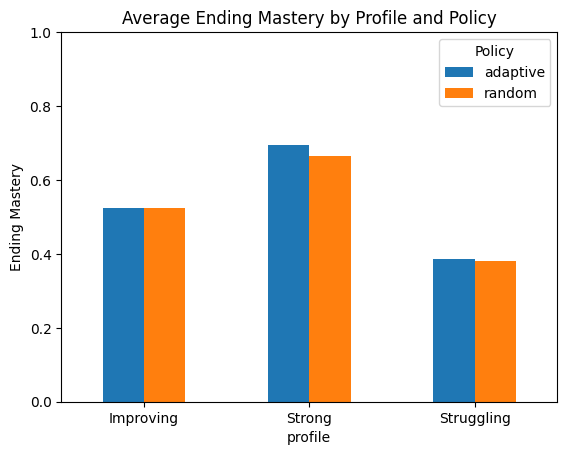

In [6]:
pivot = overall_summary.pivot(index="profile", columns="policy", values="endingMastery")

pivot.plot(kind="bar")
plt.title("Average Ending Mastery by Profile and Policy")
plt.ylabel("Ending Mastery")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Policy")
plt.show()

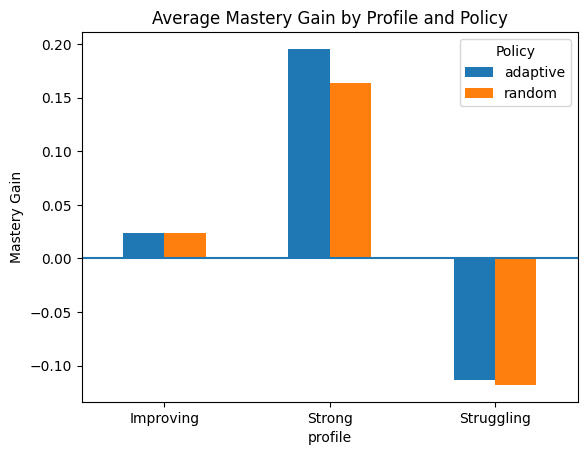

In [7]:
pivot = overall_summary.pivot(index="profile", columns="policy", values="masteryGain")

pivot.plot(kind="bar")
plt.title("Average Mastery Gain by Profile and Policy")
plt.ylabel("Mastery Gain")
plt.xticks(rotation=0)
plt.axhline(0)
plt.legend(title="Policy")
plt.show()

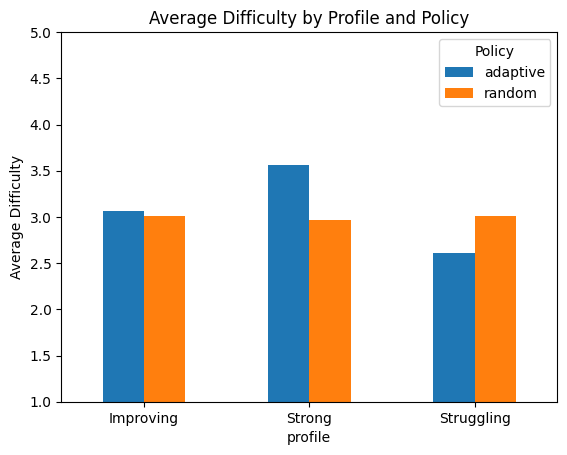

In [8]:
pivot = overall_summary.pivot(index="profile", columns="policy", values="avgDifficulty")

pivot.plot(kind="bar")
plt.title("Average Difficulty by Profile and Policy")
plt.ylabel("Average Difficulty")
plt.ylim(1, 5)
plt.xticks(rotation=0)
plt.legend(title="Policy")
plt.show()

In [9]:
comparison_table = (
    session_df
    .groupby(["profile", "policy"])
    .agg({
        "endingMastery": ["mean", "std"],
        "masteryGain": ["mean", "std"],
        "accuracy": ["mean", "std"],
        "avgDifficulty": ["mean", "std"]
    })
    .round(3)
)

comparison_table

endingMastery        masteryGain        accuracy         \
                             mean    std        mean    std     mean    std   
profile    policy                                                             
Improving  adaptive         0.524  0.076       0.024  0.076    0.512  0.046   
           random           0.523  0.072       0.023  0.072    0.519  0.045   
Strong     adaptive         0.695  0.066       0.195  0.066    0.751  0.039   
           random           0.664  0.059       0.164  0.059    0.797  0.039   
Struggling adaptive         0.387  0.068      -0.113  0.068    0.320  0.038   
           random           0.382  0.059      -0.118  0.059    0.277  0.048   

                    avgDifficulty         
                             mean    std  
profile    policy                         
Improving  adaptive         3.068  0.108  
           random           3.005  0.129  
Strong     adaptive         3.561  0.095  
           random           2.966  0.123  
Struggling adaptive         2.605  0.130  
           random           3.014  0.114

In [10]:
attempt_df["attempt"] = pd.to_numeric(attempt_df["attempt"])
attempt_df["difficulty"] = pd.to_numeric(attempt_df["difficulty"])
attempt_df["newMastery"] = pd.to_numeric(attempt_df["newMastery"])

attempt_df["bin"] = ((attempt_df["attempt"] - 1) // 10) * 10 + 1

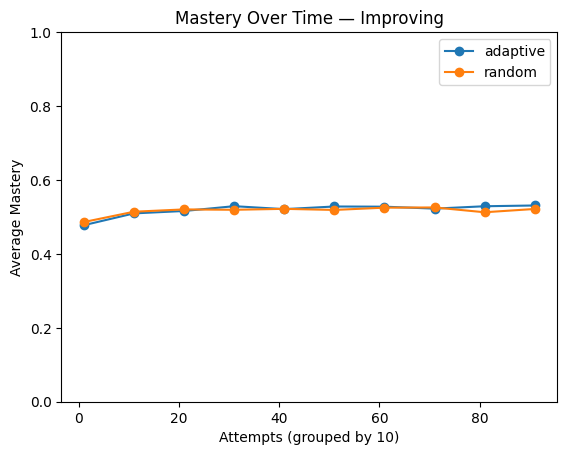

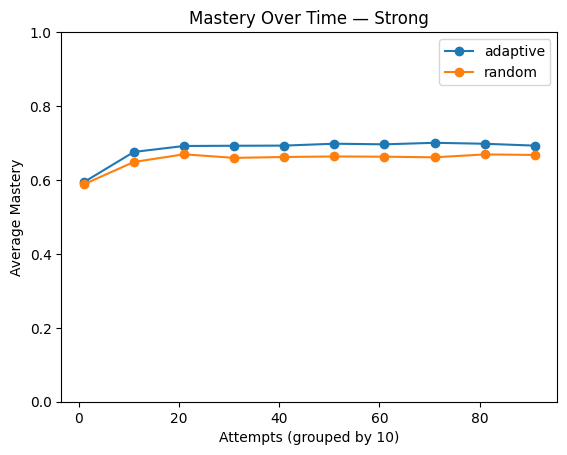

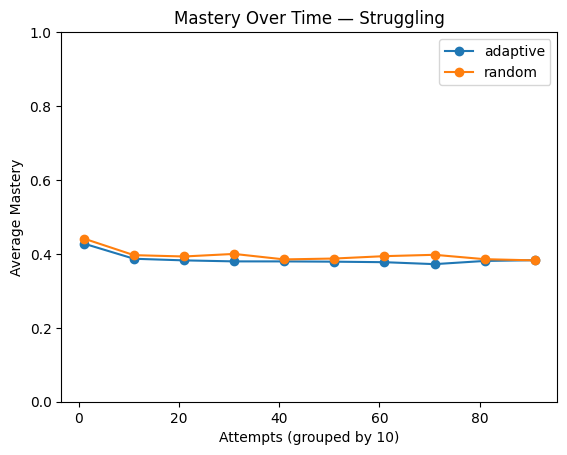

In [11]:
grouped = (
    attempt_df
    .groupby(["profile", "policy", "bin"])
    .agg({"newMastery": "mean"})
    .reset_index()
)

for profile in grouped["profile"].unique():
    plt.figure()

    subset = grouped[grouped["profile"] == profile]

    for policy in subset["policy"].unique():
        df = subset[subset["policy"] == policy].sort_values("bin")
        plt.plot(df["bin"], df["newMastery"], marker="o", label=policy)

    plt.title(f"Mastery Over Time — {profile}")
    plt.xlabel("Attempts (grouped by 10)")
    plt.ylabel("Average Mastery")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

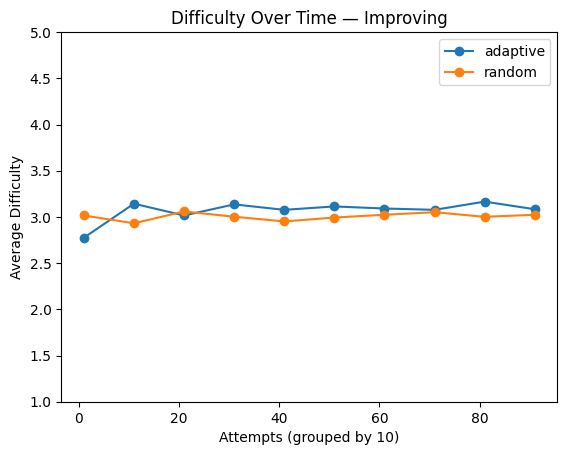

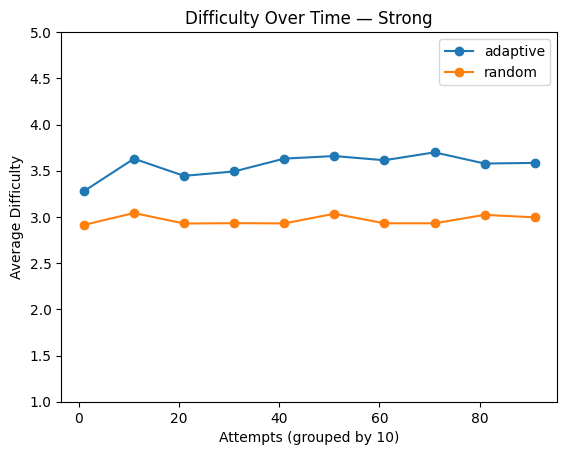

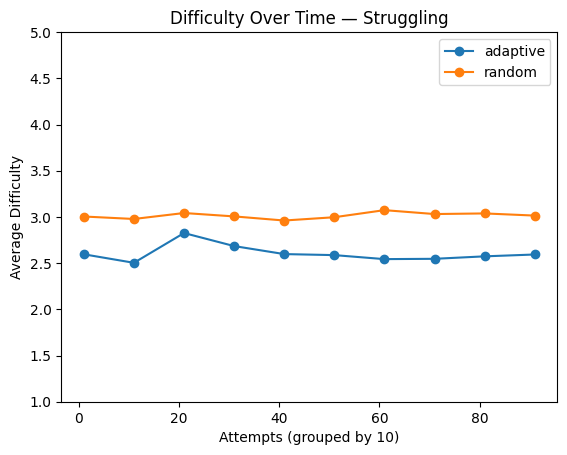

In [12]:
grouped = (
    attempt_df
    .groupby(["profile", "policy", "bin"])
    .agg({"difficulty": "mean"})
    .reset_index()
)

for profile in grouped["profile"].unique():
    plt.figure()

    subset = grouped[grouped["profile"] == profile]

    for policy in subset["policy"].unique():
        df = subset[subset["policy"] == policy].sort_values("bin")
        plt.plot(df["bin"], df["difficulty"], marker="o", label=policy)

    plt.title(f"Difficulty Over Time — {profile}")
    plt.xlabel("Attempts (grouped by 10)")
    plt.ylabel("Average Difficulty")
    plt.ylim(1, 5)
    plt.legend()
    plt.show()